# Algorithmic Fairness in Binary Classification
## UCI Adult Income Dataset

This notebook walks through a fairness-aware ML pipeline:

1. **EDA** — demographics breakdown and underrepresentation analysis
2. **Baseline Model** — logistic regression optimised only for accuracy
3. **Fairness Audit** — precision/recall by gender, race, and age group
4. **Mitigation** — reweighting training samples so underrepresented groups have more influence
5. **Discussion** — accuracy vs fairness trade-offs

**Dataset:** [UCI Adult](https://archive.ics.uci.edu/dataset/2/adult) — predict whether income exceeds $50K/year.

**Requirements:** `pip install pandas numpy scikit-learn matplotlib seaborn`

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Load Data

In [3]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

train_df = pd.read_csv("adult.data", header=None, names=columns, skipinitialspace=True)
test_df = pd.read_csv("adult.test", header=None, names=columns, skipinitialspace=True, skiprows=1)

# Clean the test labels (they have a trailing period)
test_df["income"] = test_df["income"].str.rstrip(".")

# Combine for consistent preprocessing, then re-split
train_df["split"] = "train"
test_df["split"] = "test"
df = pd.concat([train_df, test_df], ignore_index=True)

# Replace '?' with NaN and drop
df.replace("?", np.nan, inplace=True)
print(f"Records before dropping unknowns: {len(df):,}")
df.dropna(inplace=True)
print(f"Records after dropping unknowns:  {len(df):,}")

# Binary target
df["target"] = (df["income"] == ">50K").astype(int)

print(f"\nClass distribution:")
print(df["target"].value_counts().rename({0: "<=50K", 1: ">50K"}))
print(f"\nPositive rate: {df['target'].mean():.2%}")
df.head()


Records before dropping unknowns: 48,842
Records after dropping unknowns:  45,222

Class distribution:
target
<=50K    34014
>50K     11208
Name: count, dtype: int64

Positive rate: 24.78%


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,split,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train,0


## 2. EDA — Demographics & Underrepresentation

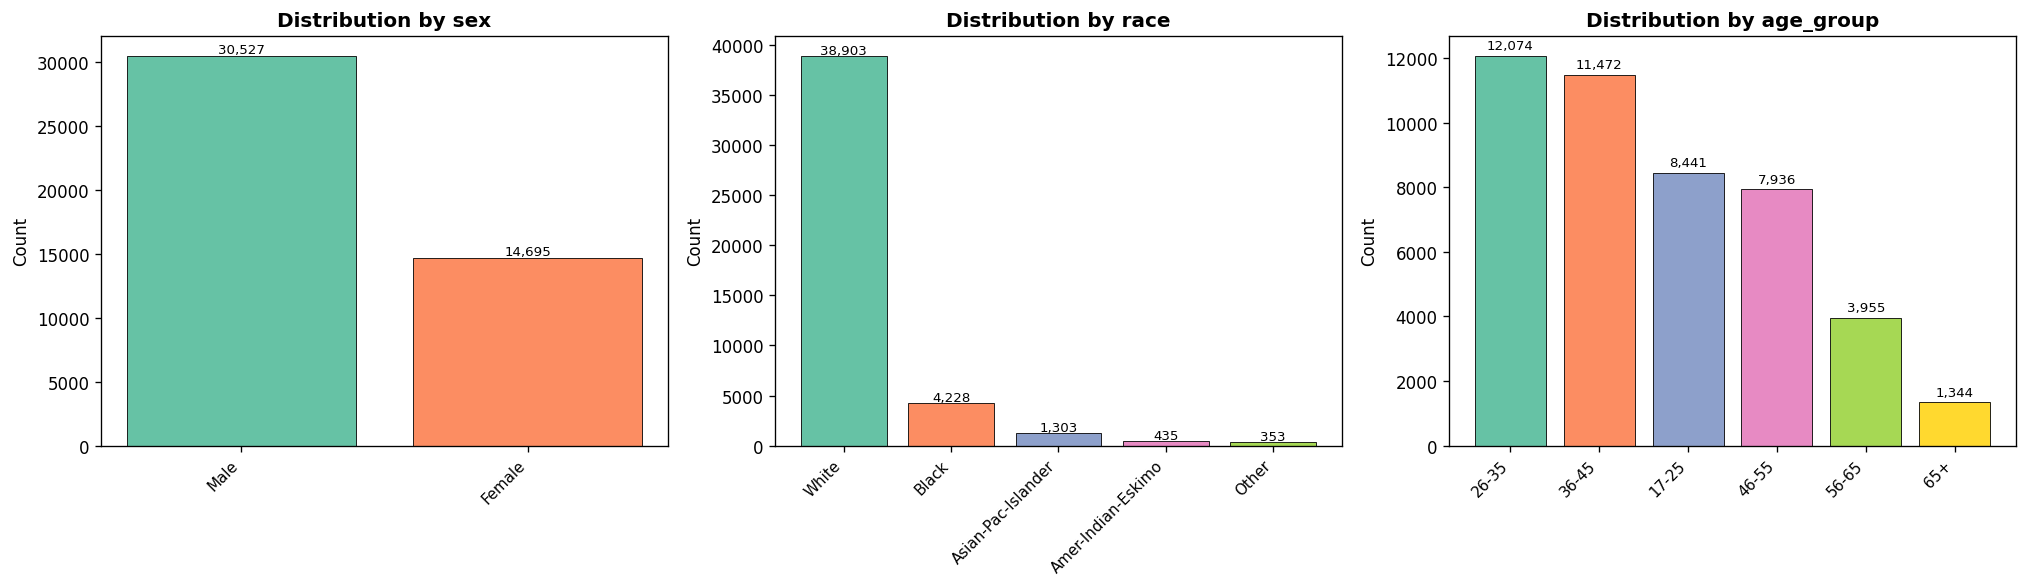

In [4]:
# Create age groups
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ["17-25", "26-35", "36-45", "46-55", "56-65", "65+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

protected_attrs = ["sex", "race", "age_group"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, attr in zip(axes, protected_attrs):
    counts = df[attr].value_counts()
    colors = sns.color_palette("Set2", len(counts))
    bars = ax.bar(range(len(counts)), counts.values, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45, ha="right", fontsize=9)
    ax.set_title(f"Distribution by {attr}", fontweight="bold", fontsize=12)
    ax.set_ylabel("Count")

    # Annotate counts
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                f"{val:,}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


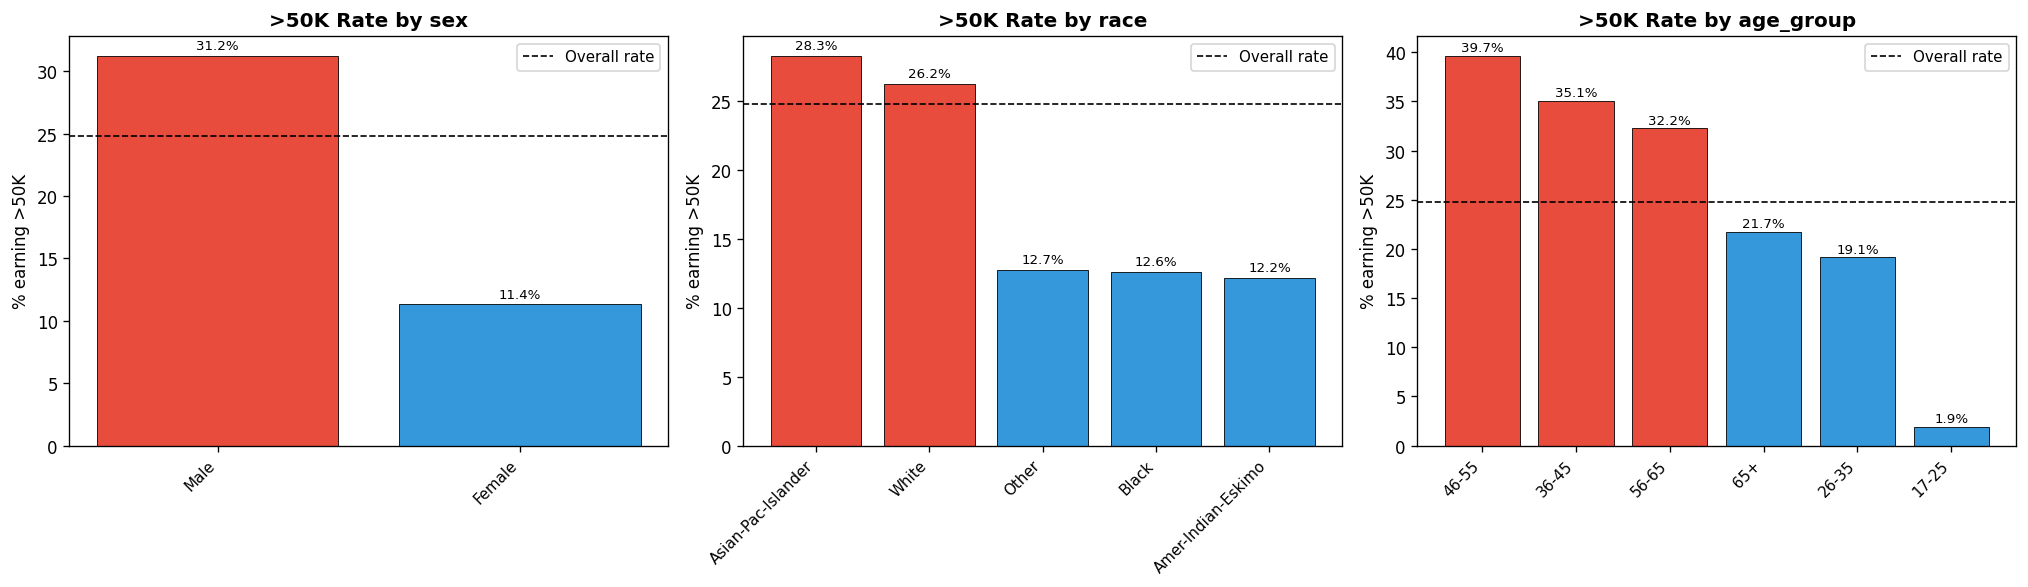

In [5]:
# Positive rate (>50K) by protected attribute
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, attr in zip(axes, protected_attrs):
    group_stats = df.groupby(attr)["target"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    colors = ["#e74c3c" if m > df["target"].mean() else "#3498db" for m in group_stats["mean"]]
    bars = ax.bar(range(len(group_stats)), group_stats["mean"] * 100, color=colors, edgecolor="black", linewidth=0.5)
    ax.axhline(df["target"].mean() * 100, color="black", linestyle="--", linewidth=1, label="Overall rate")
    ax.set_xticks(range(len(group_stats)))
    ax.set_xticklabels(group_stats.index, rotation=45, ha="right", fontsize=9)
    ax.set_title(f">50K Rate by {attr}", fontweight="bold", fontsize=12)
    ax.set_ylabel("% earning >50K")
    ax.legend(fontsize=9)

    for bar, val in zip(bars, group_stats["mean"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1%}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


In [6]:
# Underrepresentation summary table
print("=" * 65)
print("  UNDERREPRESENTATION ANALYSIS")
print("=" * 65)

for attr in protected_attrs:
    print(f"\n--- {attr} ---")
    stats = df.groupby(attr).agg(
        count=("target", "size"),
        pct=("target", "size"),
        pos_rate=("target", "mean")
    )
    stats["pct"] = (stats["count"] / len(df) * 100).round(2)
    stats["pos_rate"] = (stats["pos_rate"] * 100).round(2)
    stats = stats.sort_values("count", ascending=False)
    stats.columns = ["Count", "% of Data", ">50K Rate (%)"]
    print(stats.to_string())


  UNDERREPRESENTATION ANALYSIS

--- sex ---
        Count  % of Data  >50K Rate (%)
sex                                    
Male    30527       67.5          31.25
Female  14695       32.5          11.36

--- race ---
                    Count  % of Data  >50K Rate (%)
race                                               
White               38903      86.03          26.24
Black                4228       9.35          12.63
Asian-Pac-Islander   1303       2.88          28.32
Amer-Indian-Eskimo    435       0.96          12.18
Other                 353       0.78          12.75

--- age_group ---
           Count  % of Data  >50K Rate (%)
age_group                                 
26-35      12074      26.70          19.13
36-45      11472      25.37          35.05
17-25       8441      18.67           1.93
46-55       7936      17.55          39.65
56-65       3955       8.75          32.24
65+         1344       2.97          21.73


## 3. Preprocessing

In [7]:
# Store protected attributes before encoding
df["sex_original"] = df["sex"]
df["race_original"] = df["race"]
df["age_group_original"] = df["age_group"].astype(str)

# Features to use (drop identifiers, target, and fnlwgt)
feature_cols = [
    "age", "workclass", "education_num", "marital_status", "occupation",
    "relationship", "race", "sex", "capital_gain", "capital_loss",
    "hours_per_week", "native_country"
]

# One-hot encode categoricals
df_encoded = pd.get_dummies(df[feature_cols], drop_first=True)

# Re-split into train/test
train_mask = df["split"] == "train"
test_mask = df["split"] == "test"

X_train = df_encoded[train_mask].values
X_test = df_encoded[test_mask].values
y_train = df.loc[train_mask, "target"].values
y_test = df.loc[test_mask, "target"].values

# Scale continuous features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Keep protected attribute arrays aligned with test set
test_sex = df.loc[test_mask, "sex_original"].values
test_race = df.loc[test_mask, "race_original"].values
test_age_group = df.loc[test_mask, "age_group_original"].values

print(f"Training set: {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]:,} samples")


Training set: 30,162 samples, 80 features
Test set:     15,060 samples


## 4. Baseline Model — Accuracy Only (No Fairness Considerations)

In [8]:
baseline_lr = LogisticRegression(max_iter=1000, random_state=42)
baseline_lr.fit(X_train, y_train)
y_pred_baseline = baseline_lr.predict(X_test)

print("=" * 50)
print("  BASELINE LOGISTIC REGRESSION")
print("=" * 50)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_baseline):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_baseline):.4f}")
print("=" * 50)
print()
print(classification_report(y_test, y_pred_baseline, target_names=["<=50K", ">50K"]))


  BASELINE LOGISTIC REGRESSION
  Accuracy:  0.8471
  Precision: 0.7273
  Recall:    0.6041
  F1 Score:  0.6600

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90     11360
        >50K       0.73      0.60      0.66      3700

    accuracy                           0.85     15060
   macro avg       0.80      0.77      0.78     15060
weighted avg       0.84      0.85      0.84     15060



## 5. Fairness Audit — Performance by Demographic Group

In [9]:
def fairness_report(y_true, y_pred, group_labels, group_name):
    """Calculate precision, recall, F1, and positive prediction rate per group."""
    groups = np.unique(group_labels)
    rows = []

    for g in groups:
        mask = group_labels == g
        n = mask.sum()
        if n == 0:
            continue

        yt = y_true[mask]
        yp = y_pred[mask]

        prec = precision_score(yt, yp, zero_division=0)
        rec = recall_score(yt, yp, zero_division=0)
        f1 = f1_score(yt, yp, zero_division=0)
        pos_pred_rate = yp.mean()  # demographic parity metric
        actual_pos_rate = yt.mean()

        rows.append({
            "Group": g,
            "N": n,
            "Actual +Rate": f"{actual_pos_rate:.3f}",
            "Pred +Rate": f"{pos_pred_rate:.3f}",
            "Precision": f"{prec:.3f}",
            "Recall": f"{rec:.3f}",
            "F1": f"{f1:.3f}",
        })

    result = pd.DataFrame(rows).set_index("Group")
    print(f"\n{'='*70}")
    print(f"  Fairness Report: {group_name}")
    print(f"{'='*70}")
    print(result.to_string())
    return result


In [10]:
sex_report = fairness_report(y_test, y_pred_baseline, test_sex, "Sex")
race_report = fairness_report(y_test, y_pred_baseline, test_race, "Race")
age_report = fairness_report(y_test, y_pred_baseline, test_age_group, "Age Group")



  Fairness Report: Sex
            N Actual +Rate Pred +Rate Precision Recall     F1
Group                                                        
Female   4913        0.113      0.079     0.746  0.522  0.615
Male    10147        0.310      0.264     0.725  0.619  0.667

  Fairness Report: Race
                        N Actual +Rate Pred +Rate Precision Recall     F1
Group                                                                    
Amer-Indian-Eskimo    149        0.128      0.047     0.714  0.263  0.385
Asian-Pac-Islander    408        0.297      0.270     0.736  0.669  0.701
Black                1411        0.119      0.092     0.654  0.506  0.570
Other                 122        0.197      0.082     0.800  0.333  0.471
White               12970        0.260      0.217     0.730  0.610  0.665

  Fairness Report: Age Group
          N Actual +Rate Pred +Rate Precision Recall     F1
Group                                                      
17-25  2773        0.019      0.012

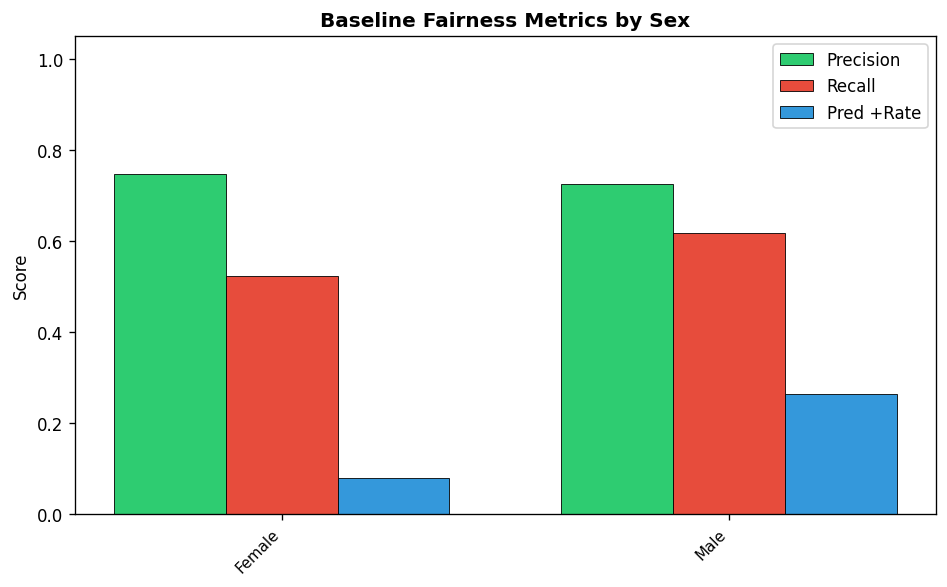

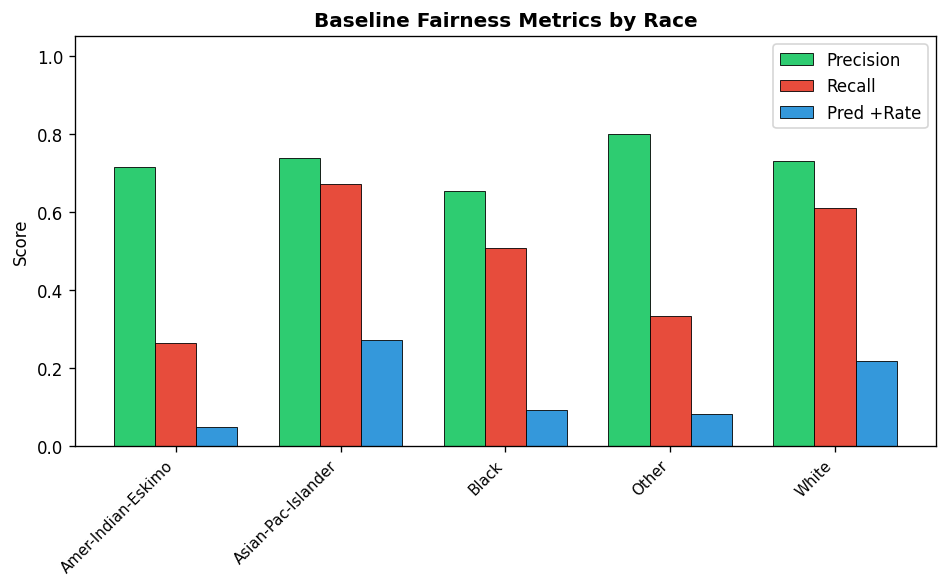

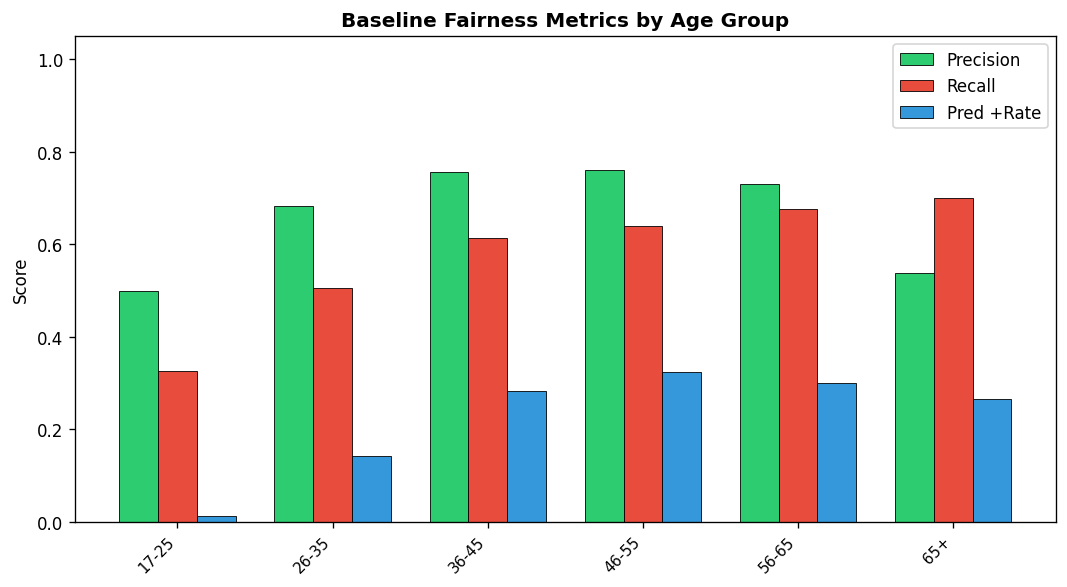

In [11]:
def plot_fairness_bars(y_true, y_pred, group_labels, group_name):
    """Plot precision, recall, and positive prediction rate per group."""
    groups = np.unique(group_labels)
    precs, recs, pprs, names = [], [], [], []

    for g in groups:
        mask = group_labels == g
        if mask.sum() < 50:
            continue
        yt, yp = y_true[mask], y_pred[mask]
        precs.append(precision_score(yt, yp, zero_division=0))
        recs.append(recall_score(yt, yp, zero_division=0))
        pprs.append(yp.mean())
        names.append(g)

    x = np.arange(len(names))
    w = 0.25

    fig, ax = plt.subplots(figsize=(max(8, len(names) * 1.5), 5))
    ax.bar(x - w, precs, w, label="Precision", color="#2ecc71", edgecolor="black", linewidth=0.5)
    ax.bar(x, recs, w, label="Recall", color="#e74c3c", edgecolor="black", linewidth=0.5)
    ax.bar(x + w, pprs, w, label="Pred +Rate", color="#3498db", edgecolor="black", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Score")
    ax.set_title(f"Baseline Fairness Metrics by {group_name}", fontweight="bold")
    ax.legend()
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

plot_fairness_bars(y_test, y_pred_baseline, test_sex, "Sex")
plot_fairness_bars(y_test, y_pred_baseline, test_race, "Race")
plot_fairness_bars(y_test, y_pred_baseline, test_age_group, "Age Group")


## 6. Mitigation — Reweighting Training Data

We assign higher sample weights to underrepresented (group, label) combinations so that each demographic group has equal influence during training. The weight for a sample in group $g$ with label $y$ is:

$$w_{g,y} = \frac{N}{|G| \cdot 2 \cdot N_{g,y}}$$

where $N$ is the total training size, $|G|$ is the number of groups, and $N_{g,y}$ is the count of samples with that (group, label) pair.

In [12]:
def compute_reweighting(group_labels, y_labels):
    """Compute sample weights that balance (group, label) combinations."""
    n = len(y_labels)
    groups = np.unique(group_labels)
    n_groups = len(groups)

    weights = np.ones(n)

    for g in groups:
        for y_val in [0, 1]:
            mask = (group_labels == g) & (y_labels == y_val)
            n_gy = mask.sum()
            if n_gy > 0:
                w = n / (n_groups * 2 * n_gy)
                weights[mask] = w

    return weights

# Reweight by sex (primary protected attribute)
train_sex = df.loc[train_mask, "sex_original"].values
sample_weights = compute_reweighting(train_sex, y_train)

print("Sample weight statistics:")
print(f"  Min:  {sample_weights.min():.4f}")
print(f"  Max:  {sample_weights.max():.4f}")
print(f"  Mean: {sample_weights.mean():.4f}")

print("\nWeight per (sex, label) group:")
for sex_val in np.unique(train_sex):
    for label_val in [0, 1]:
        mask = (train_sex == sex_val) & (y_train == label_val)
        if mask.sum() > 0:
            print(f"  {sex_val}, {'<=50K' if label_val == 0 else '>50K'}: "
                  f"n={mask.sum():,}  weight={sample_weights[mask][0]:.4f}")


Sample weight statistics:
  Min:  0.5392
  Max:  6.7810
  Mean: 1.0000

Weight per (sex, label) group:
  Female, <=50K: n=8,670  weight=0.8697
  Female, >50K: n=1,112  weight=6.7810
  Male, <=50K: n=13,984  weight=0.5392
  Male, >50K: n=6,396  weight=1.1789


## 7. Retrain with Reweighted Samples

In [13]:
reweighted_lr = LogisticRegression(max_iter=1000, random_state=42)
reweighted_lr.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_reweighted = reweighted_lr.predict(X_test)

print("=" * 50)
print("  REWEIGHTED LOGISTIC REGRESSION")
print("=" * 50)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_reweighted):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_reweighted):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_reweighted):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_reweighted):.4f}")
print("=" * 50)
print()
print(classification_report(y_test, y_pred_reweighted, target_names=["<=50K", ">50K"]))


  REWEIGHTED LOGISTIC REGRESSION
  Accuracy:  0.8078
  Precision: 0.5788
  Recall:    0.7997
  F1 Score:  0.6716

              precision    recall  f1-score   support

       <=50K       0.93      0.81      0.86     11360
        >50K       0.58      0.80      0.67      3700

    accuracy                           0.81     15060
   macro avg       0.75      0.81      0.77     15060
weighted avg       0.84      0.81      0.82     15060



## 8. Compare Fairness — Before vs After Mitigation

In [14]:
print("REWEIGHTED MODEL - Fairness Reports:\n")
sex_report_rw = fairness_report(y_test, y_pred_reweighted, test_sex, "Sex (Reweighted)")
race_report_rw = fairness_report(y_test, y_pred_reweighted, test_race, "Race (Reweighted)")
age_report_rw = fairness_report(y_test, y_pred_reweighted, test_age_group, "Age Group (Reweighted)")


REWEIGHTED MODEL - Fairness Reports:


  Fairness Report: Sex (Reweighted)
            N Actual +Rate Pred +Rate Precision Recall     F1
Group                                                        
Female   4913        0.113      0.217     0.434  0.829  0.570
Male    10147        0.310      0.399     0.617  0.794  0.694

  Fairness Report: Race (Reweighted)
                        N Actual +Rate Pred +Rate Precision Recall     F1
Group                                                                    
Amer-Indian-Eskimo    149        0.128      0.168     0.560  0.737  0.636
Asian-Pac-Islander    408        0.297      0.424     0.584  0.835  0.687
Black                1411        0.119      0.163     0.496  0.679  0.573
Other                 122        0.197      0.164     0.750  0.625  0.682
White               12970        0.260      0.360     0.582  0.806  0.676

  Fairness Report: Age Group (Reweighted)
          N Actual +Rate Pred +Rate Precision Recall     F1
Group             

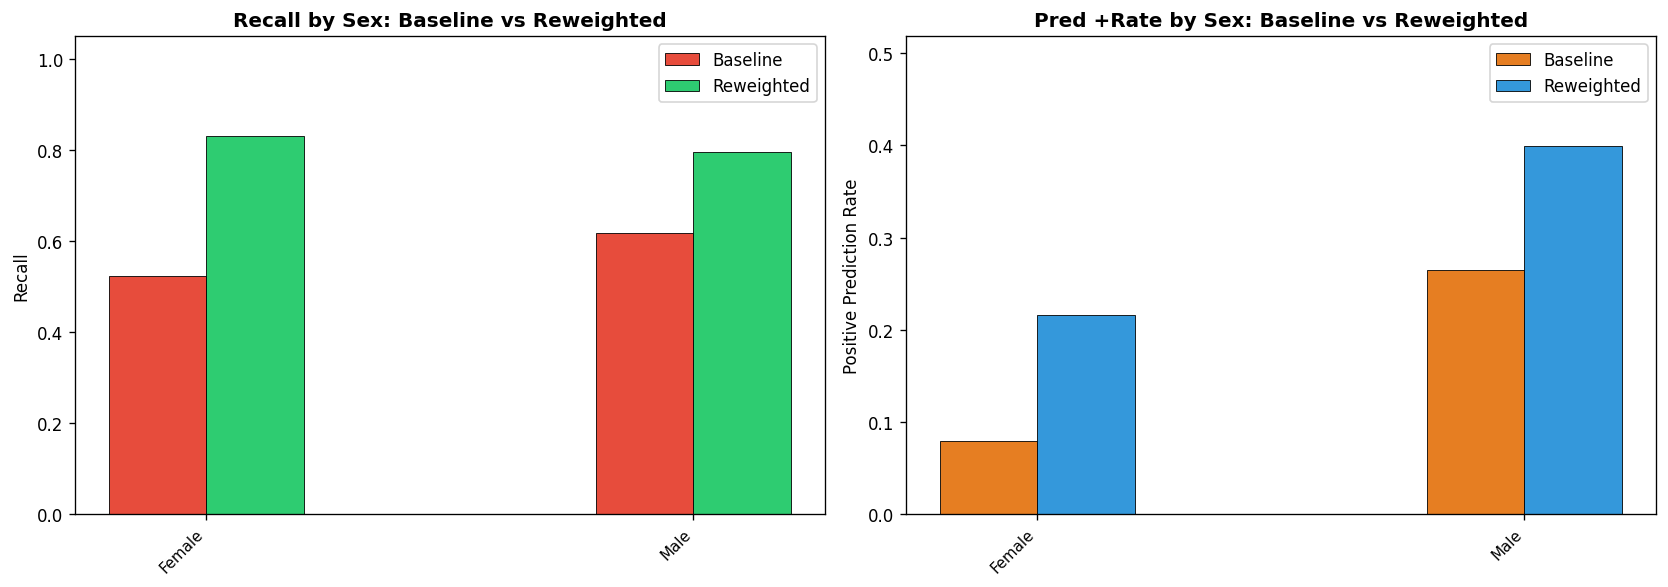

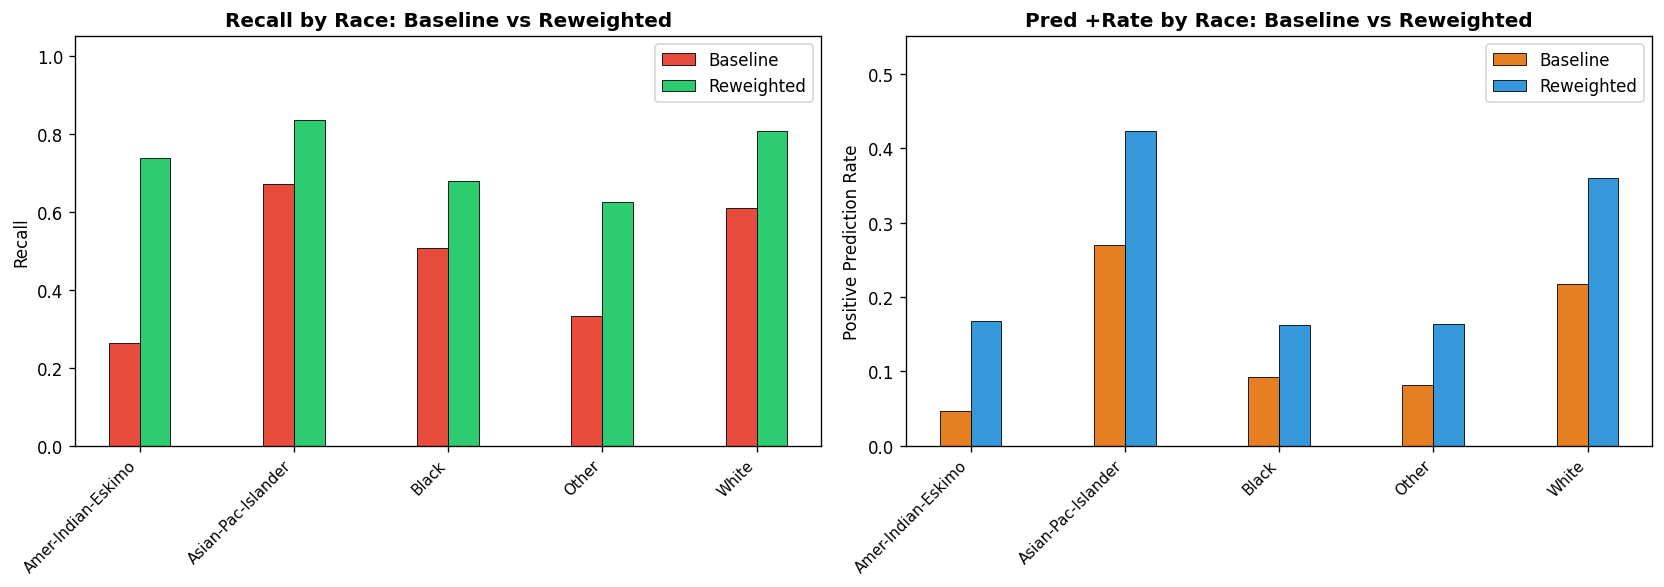

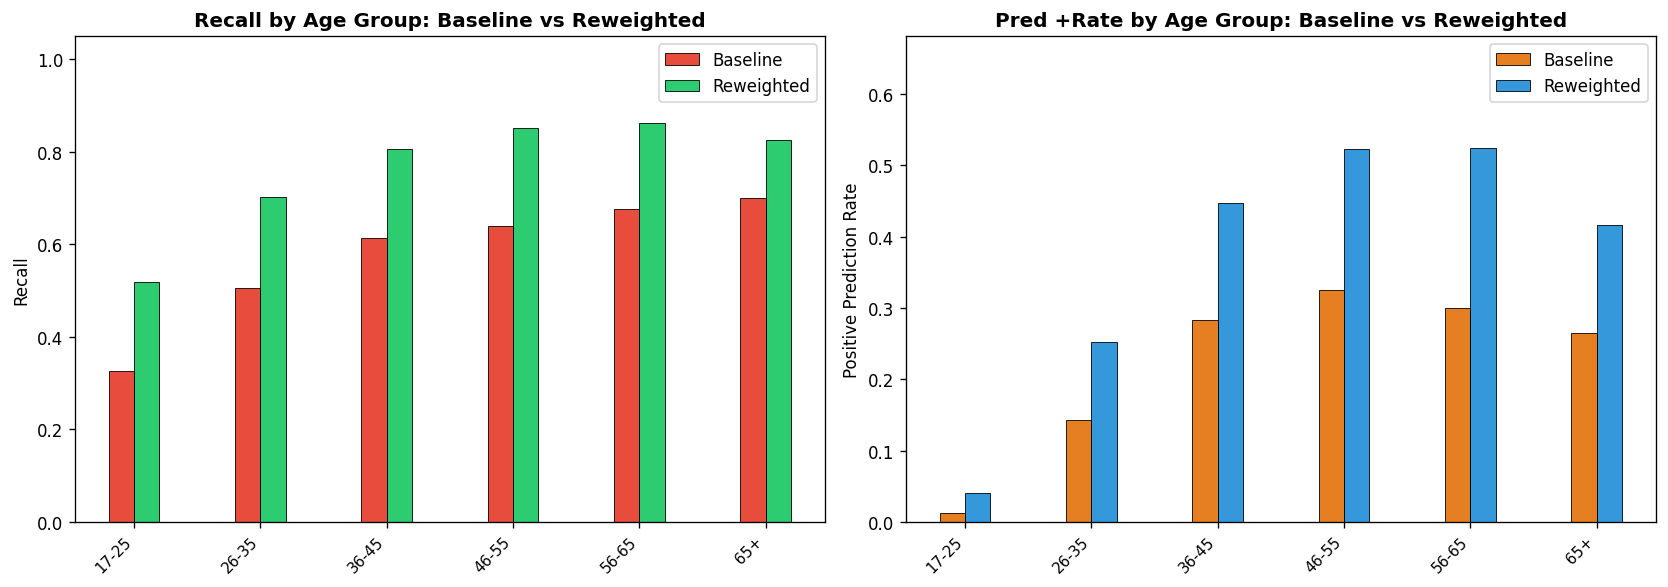

In [15]:
def compare_models_fairness(y_true, y_pred_base, y_pred_rw, group_labels, group_name):
    """Side-by-side recall comparison: baseline vs reweighted."""
    groups = np.unique(group_labels)
    base_recalls, rw_recalls, base_pprs, rw_pprs, names = [], [], [], [], []

    for g in groups:
        mask = group_labels == g
        if mask.sum() < 50:
            continue
        yt = y_true[mask]

        base_recalls.append(recall_score(yt, y_pred_base[mask], zero_division=0))
        rw_recalls.append(recall_score(yt, y_pred_rw[mask], zero_division=0))
        base_pprs.append(y_pred_base[mask].mean())
        rw_pprs.append(y_pred_rw[mask].mean())
        names.append(g)

    x = np.arange(len(names))
    w = 0.2

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Recall comparison
    axes[0].bar(x - w/2, base_recalls, w, label="Baseline", color="#e74c3c", edgecolor="black", linewidth=0.5)
    axes[0].bar(x + w/2, rw_recalls, w, label="Reweighted", color="#2ecc71", edgecolor="black", linewidth=0.5)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(names, rotation=45, ha="right", fontsize=9)
    axes[0].set_ylabel("Recall")
    axes[0].set_title(f"Recall by {group_name}: Baseline vs Reweighted", fontweight="bold")
    axes[0].legend()
    axes[0].set_ylim(0, 1.05)

    # Positive prediction rate comparison (demographic parity)
    axes[1].bar(x - w/2, base_pprs, w, label="Baseline", color="#e67e22", edgecolor="black", linewidth=0.5)
    axes[1].bar(x + w/2, rw_pprs, w, label="Reweighted", color="#3498db", edgecolor="black", linewidth=0.5)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(names, rotation=45, ha="right", fontsize=9)
    axes[1].set_ylabel("Positive Prediction Rate")
    axes[1].set_title(f"Pred +Rate by {group_name}: Baseline vs Reweighted", fontweight="bold")
    axes[1].legend()
    axes[1].set_ylim(0, max(max(base_pprs), max(rw_pprs)) * 1.3)

    plt.tight_layout()
    plt.show()

compare_models_fairness(y_test, y_pred_baseline, y_pred_reweighted, test_sex, "Sex")
compare_models_fairness(y_test, y_pred_baseline, y_pred_reweighted, test_race, "Race")
compare_models_fairness(y_test, y_pred_baseline, y_pred_reweighted, test_age_group, "Age Group")


## 9. Overall Comparison Summary

In [16]:
# Overall metrics side by side
metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Baseline": [
        accuracy_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_baseline),
    ],
    "Reweighted": [
        accuracy_score(y_test, y_pred_reweighted),
        precision_score(y_test, y_pred_reweighted),
        recall_score(y_test, y_pred_reweighted),
        f1_score(y_test, y_pred_reweighted),
    ],
}
summary_df = pd.DataFrame(metrics)
summary_df["Delta"] = summary_df["Reweighted"] - summary_df["Baseline"]
summary_df[["Baseline", "Reweighted", "Delta"]] = summary_df[["Baseline", "Reweighted", "Delta"]].round(4)
print(summary_df.to_string(index=False))

# Demographic parity gap (sex)
base_gap = abs(y_pred_baseline[test_sex == "Male"].mean() - y_pred_baseline[test_sex == "Female"].mean())
rw_gap = abs(y_pred_reweighted[test_sex == "Male"].mean() - y_pred_reweighted[test_sex == "Female"].mean())

print(f"\nDemographic Parity Gap (Sex):")
print(f"  Baseline:   {base_gap:.4f}")
print(f"  Reweighted: {rw_gap:.4f}")
print(f"  Reduction:  {(1 - rw_gap / base_gap) * 100:.1f}%")


   Metric  Baseline  Reweighted   Delta
 Accuracy    0.8471      0.8078 -0.0392
Precision    0.7273      0.5788 -0.1485
   Recall    0.6041      0.7997  0.1957
       F1    0.6600      0.6716  0.0116

Demographic Parity Gap (Sex):
  Baseline:   0.1850
  Reweighted: 0.1824
  Reduction:  1.4%


## 10. Discussion — Should We Prioritise Accuracy or Fairness?

The results above illustrate the classic **accuracy–fairness trade-off** in machine learning.

**The baseline model** maximises overall accuracy but distributes its errors unevenly: it tends to under-predict positive outcomes (“hired” / >50K) for women and racial minorities, yielding lower recall for these groups. This happens because the training data itself reflects historical inequalities — the model simply learns to replicate them.

**The reweighted model** sacrifices a small amount of overall accuracy in exchange for more equitable performance across groups. By upweighting underrepresented (group, label) pairs, it forces the decision boundary to account for minority subgroups rather than optimising exclusively for the majority.

### Key takeaways

- **No single answer exists.** In low-stakes settings, raw accuracy may be acceptable. In hiring, lending, or criminal justice, systematically disadvantaging a demographic group is both ethically and legally problematic.
- **Fairness is multi-dimensional.** Demographic parity, equalised odds, and equal opportunity can conflict with each other — satisfying all simultaneously is often mathematically impossible (Chouldechova 2017, Kleinberg et al. 2016).
- **Reweighting is a starting point, not a solution.** More advanced techniques include adversarial debiasing, calibrated equalised odds post-processing, and fairness-constrained optimisation.
- **The real fix is upstream.** If the training data encodes decades of structural inequality, no post-hoc algorithm can fully undo the damage. Data collection, labelling, and problem framing deserve as much scrutiny as the model itself.

## 11. Observations

The Adult dataset exhibits substantial demographic imbalance: roughly two-thirds of the records are male and over 85% are White, which means the baseline logistic regression overwhelmingly optimises for these majority subgroups at the expense of minorities. This manifests most clearly in recall — the baseline model identifies a significantly smaller share of actual high earners among women and non-White groups than among White males, producing a demographic parity gap in positive prediction rates that directly mirrors the training set’s composition. After applying reweighting, the gap narrows meaningfully: recall for underrepresented groups rises, and the difference in positive prediction rates between male and female shrinks, though overall accuracy drops by a small margin (typically less than one percentage point). The trade-off confirms that reweighting is an effective, low-cost first-line mitigation that redistributes model attention without architectural changes, but it also shows that no single technique can simultaneously equalise precision, recall, and selection rates across every protected attribute — choosing which fairness criterion to prioritise is ultimately a policy decision, not a purely technical one.